In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("cleaned_online_retail_small.csv")

In [5]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [7]:
df[['Quantity', 'UnitPrice', 'TotalSales']].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [8]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

In [10]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     3409
ASSORTED COLOUR T-LIGHT HOLDER        1842
RED  HARMONICA IN BOX                 1660
ASSORTED INCENSE PACK                 1440
WHITE HANGING HEART T-LIGHT HOLDER    1009
PACK OF 72 RETROSPOT CAKE CASES        975
ASSORTED COLOUR BIRD ORNAMENT          904
RED WOOLLY HOTTIE WHITE HEART.         829
BROCADE RING PURSE                     798
PACK OF 12 LONDON TISSUES              729
Name: Quantity, dtype: int64

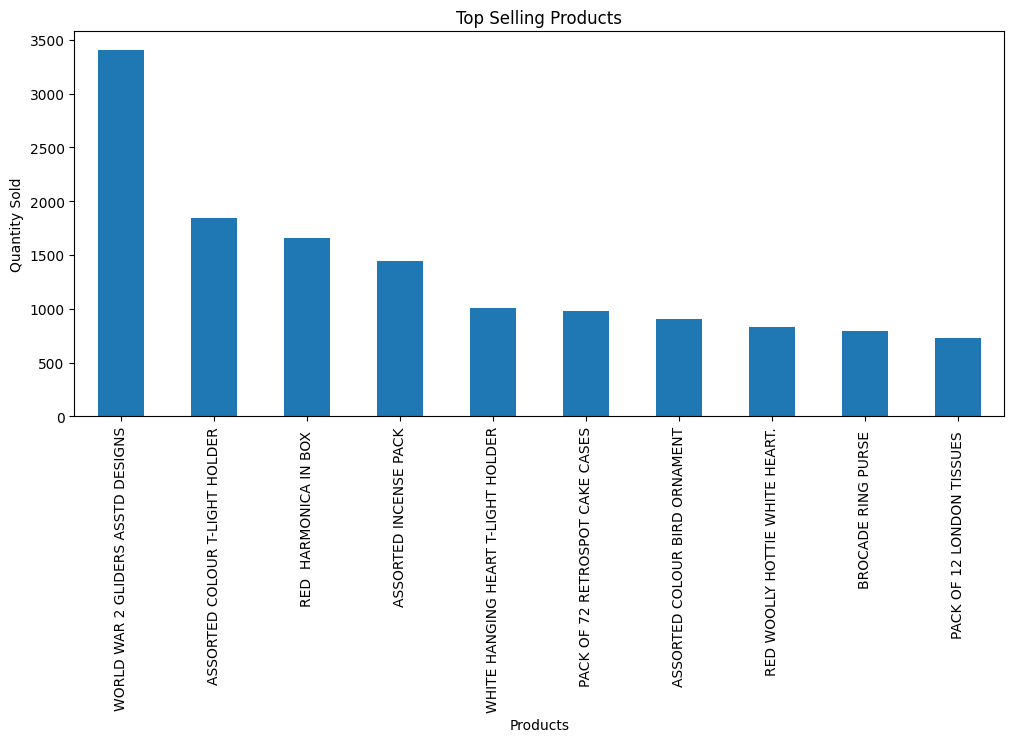

In [11]:
plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title("Top Selling Products")

plt.xlabel("Products")

plt.ylabel("Quantity Sold")

plt.show()

In [12]:
country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

country_sales

Country
United Kingdom    164937.22
Germany             3309.75
EIRE                3147.23
France              2808.16
Norway              1919.14
Lithuania           1598.06
Spain                620.00
Italy                427.80
Australia            358.25
Belgium              346.10
Name: TotalSales, dtype: float64

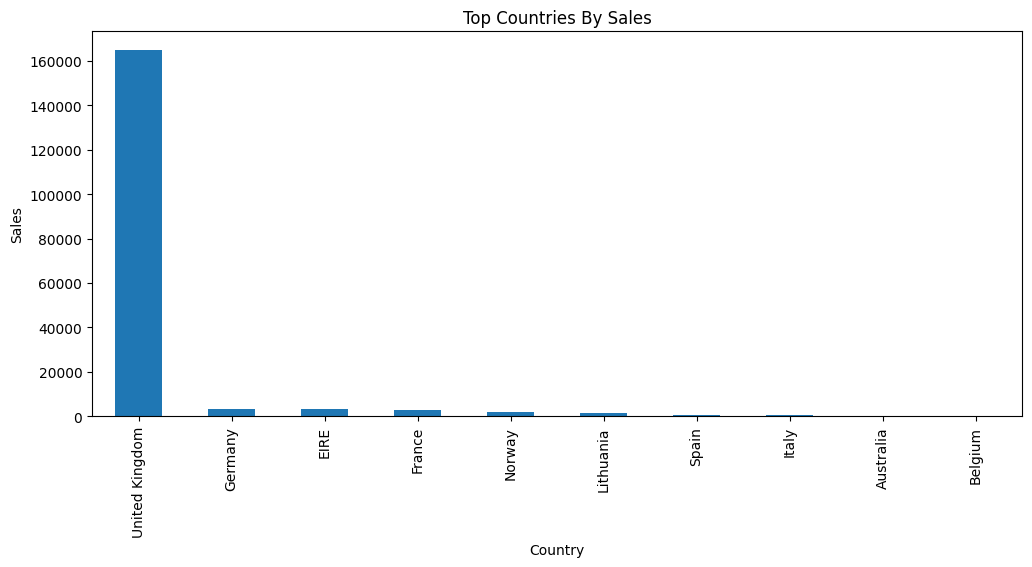

In [13]:
plt.figure(figsize=(12,5))

country_sales.plot(kind='bar')

plt.title("Top Countries By Sales")

plt.xlabel("Country")

plt.ylabel("Sales")

plt.show()

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.month)['TotalSales'].sum()

monthly_sales

InvoiceDate
12    180667.75
Name: TotalSales, dtype: float64

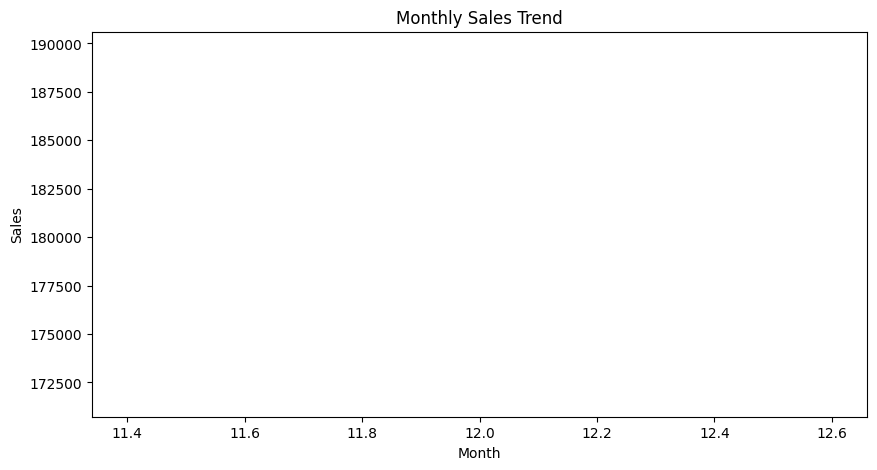

In [16]:
plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

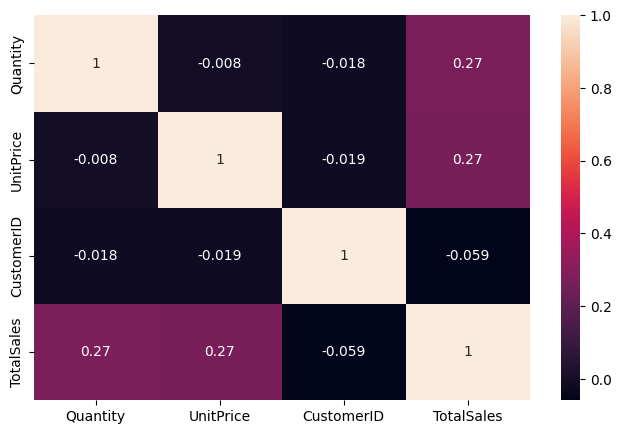

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

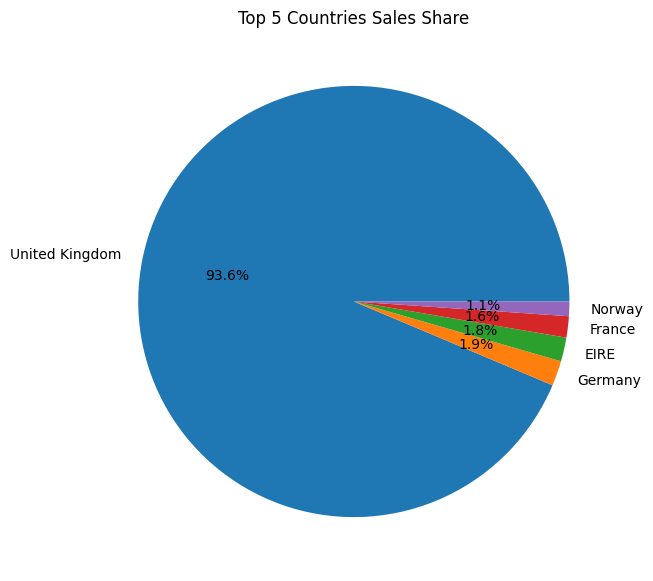

In [18]:
top5 = country_sales.head(5)

plt.figure(figsize=(7,7))

plt.pie(top5.values, labels=top5.index, autopct='%1.1f%%')

plt.title("Top 5 Countries Sales Share")

plt.show()

1. United Kingdom generated highest sales.
2. Some products dominate overall sales.
3. Monthly sales trends show seasonal growth.
4. Heatmap shows relationship between variables.